build on medical medical
* 2D and 3D image
* memorie mecanisim
* One prompt

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download
from PIL import Image
from glob import glob
from tqdm import tqdm
from collections import OrderedDict

#from skimage import measure
#import SimpleITK as sitk

from sam2.build_sam import build_sam2_video_predictor
from sam2.sam2_image_predictor import SAM2ImagePredictor

d:\marchine_learning\Projet\Segmentation\medsam2_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
imgs = np.load("D:/marchine_learning/Projet/Segmentation/BraTS2021_npz_50/BraTS2021_00147_vol_175302.npz")
img = imgs['flair']
mask = imgs['seg']

In [ ]:
# format (N, 512, 512, 3)
resized = np.zeros((img.shape[2], 512, 512, 3), dtype=np.uint8)
for i in range(img.shape[2]):
    slice = Image.fromarray(img[:, :, i])
    slice = slice.resize((512, 512))
    slice_arr = np.array(slice)
    # répéter sur 3 canaux
    resized[i] = np.repeat(slice_arr[..., np.newaxis], 3, axis=-1)

volume_rgb = resized.astype(np.float32) / 255.0

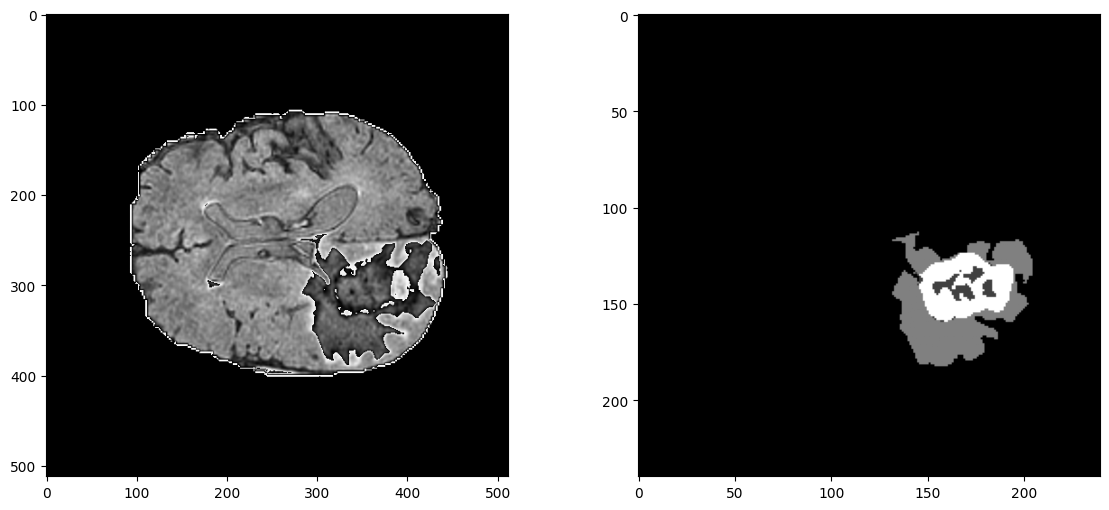

In [21]:
plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
plt.imshow(resized[77,:,:, 1], cmap='gray')
plt.subplot(1,2,2)
plt.imshow(mask[:, :, 77], cmap='gray')
plt.show()

## Points à vérifier

* Mode utilisé :
    * ImagePredictor → attend une seule image (3, H, W).
    * VideoPredictor → attend une séquence (T, 3, H, W).

* Normalisation :
    * Divisé par 255.0 .
    * Vérifie que le type est float32.

* Device :
    * to(device) doit correspondre à "cuda" ou "cpu".
    * Si tu es sur GPU, assure-toi que predictor est aussi sur le même device.

In [ ]:
checkpoint = 'D:/marchine_learning/Projet/Segmentation/MedSAM2/checkpoints/MedSAM2_latest.pt'
model_cfg = "D:/marchine_learning/Projet/Segmentation/MedSAM2/sam2/configs/sam2.1_hiera_t512.yaml"
device = 'cpu' 
predictor = build_sam2_video_predictor(model_cfg, checkpoint).to(device)
predictor.eval()

device = 'cpu'
center_slice_idx = 77
bbox = np.array([290, 260, 430, 400])   #xmin, ymin, xmax, ymax 

# Convert to torh tensor
volume_tensor = torch.from_numpy(volume_rgb).permute(0, 3, 1, 2).float().to(device)

# Initialize segmentation array
segs_3D = np.zeros((img.shape[2], 512, 512), dtype=np.uint8)

# Run inference
with torch.no_grad():
    inference_state = predictor.init_state(volume_tensor, 512, 512)

    # Forward progation
    _, _, out_mask_logit = predictor.add_new_points_or_box(
        inference_state = inference_state,
        frame_idx = center_slice_idx,
        obj_id = 1,
        box = bbox
    )
    for out_frame_idx, _ , out_mask_logits in predictor.propagate_in_video(inference_state):
        segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1

    # Backward propagation
    _, _, _ = predictor.add_new_points_or_box(
        inference_state = inference_state,
        frame_idx = center_slice_idx,
        obj_id = 1,
        box = bbox
    )
    for out_frame_idx, _ , out_mask_logits in predictor.propagate_in_video(inference_state, reverse=True):
        segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1


propagate in video: 100%|██████████| 78/78 [07:10<00:00,  5.51s/it]


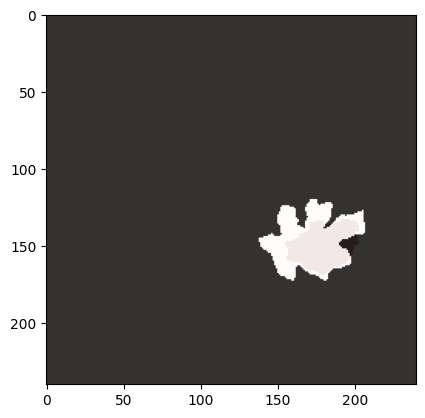

In [33]:
slice = Image.fromarray(segs_3D[60, :, :])
slice = slice.resize((240, 240))
plt.imshow(slice, alpha=0.5, cmap='Oranges')
plt.imshow(mask[:, :, 60], cmap='gray', alpha=0.8)
plt.show()

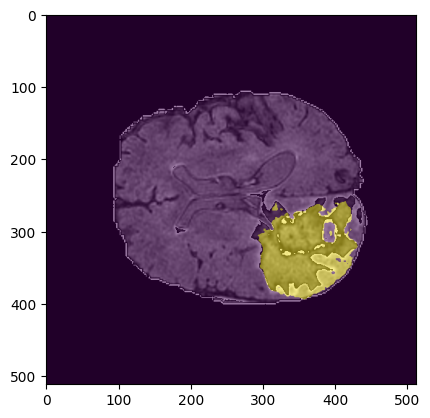

In [ ]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import matplotlib.pyplot as plt
import time

# 1. Load the model_cfg
sam2_model = build_sam2(model_cfg, checkpoint, device)
predictor = SAM2ImagePredictor(sam2_model)

# 2. Prepare the image (e.g., a CT slice)
image_np = volume_rgb[77, :, :, :] # shape (512, 512, 3), dtype float32 ou uint8 
# Si besoin, convertir en uint8 
image_np = (image_np * 255).astype(np.uint8)
predictor.set_image(image_np)

t = time.time()
# 4. Predict
masks, scores, logits = predictor.predict(
    box=bbox,
    multimask_output=False
)

print(f"Temps inference d'une coupe: {t - time.time()}")

# 5. Visualize
plt.imshow(image_np)
plt.imshow(masks[0], alpha=0.5)
plt.show()

In [ ]:
# Define helper functions
def getLargestCC(segmentation):
    labels = measure.label(segmentation)
    largestCC = labels == np.argmax(np.bincount(labels.flat)[1:])+1
    return largestCC

def show_mask(mask, ax, mask_color=None, alpha=0.5):
    if mask_color is not None:
        color = np.concatenate([mask_color, np.array([alpha])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, alpha])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

In [ ]:
def show_box(box, ax, edgecolor='blue'):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor=edgecolor, facecolor=(0,0,0,0), lw = 2))

def preprocess_volume(volume_path):
    volume = sitk.ReadImage(volume_path)
    volume_array = sitk.GetArrayFromImage(volume)

    # Normalize to [0, 255]
    volume_array = (volume_array - volume_array.min()) / (volume_array.max() - volume_array.min()) * 255
    return volume_array.astype(np.uint8)

def resize_to_512(array_3d):
    resized = np.zeros((array_3d.shape[0], 512, 512), dtype=np.uint8)
    for i in range(array_3d.shape[0]):
        img = Image.fromarray(array_3d[i])
        img = img.resize((512, 512))
        resized[i] = np.array(img)
    return resized

In [ ]:
def run_inference(volume_array, predictor, center_slice_idx, bbox, device):
    volume_resized = resize_to_512(volume_array)

    # Convert to RGB format expected by MedSAM2
    volume_rgb = np.stack([volume_resized]*3, axis=1)
    volume_rgb = volume_rgb / 255.0

    # Normalize with Imagenet stats
    img_mean = np.array([0.485, 0.456, 0.406])[:, None, None]
    img_std = np.array([0.229, 0.224, 0.225])[:, None, None]
    volume_rgb = (volume_rgb - img_mean) / img_std

    # Convert to torh tensor
    volume_tensor = torch.from_numpy(volume_rgb).float().float().to(device)

    # Initialize segmentation array
    segs_3D = np.zeros(volume_resized.shape, dtype=np.uint8)

    # Run inference
    with torch.no_grad():
        inference_state = predictor.init_state(volume_tensor, 512, 512)

        # Forward progation
        _, _, _ = predictor.add_new_points_or_box(
            inference_state = inference_state,
            frame_idx = center_slice_idx,
            obj_id = 1,
            box = bbox
        )
        for out_frame_idx, _ , out_mask_logits in predictor.propagate_in_video(inference_state):
            segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1

        # Backward propagation
        _, _, _ = predictor.add_new_points_or_box(
            inference_state = inference_state,
            frame_idx = center_slice_idx,
            obj_id = 1,
            box = bbox
        )
        for out_frame_idx, _ , out_mask_logits in predictor.propagate_in_video(inference_state, reversed=True):
            segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1

        # post-process segmentation
        if np.max(segs_3D) > 0:
            segs_3D = getLargestCC(segs_3D)
        
        return segs_3D.astype(np.uint8)


In [ ]:
volume = preprocess_volume("volume_ path")
center_slice_idx = volume.shape[0] // 2
bbox = np.array([128, 128, 384, 384]) #xmin, ymin, xmax, ymax in 512x512 space

# Run inference
device = 'CUDA'
segmentation = run_inference(volume, predictor, center_slice_idx, bbox, device)

In [ ]:
# Visualization
def visualize_results(volume, segmentation, slice_idx):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original slice
    axes[0].imshow(volume[slice_idx], cmap='gray')
    axes[0].set_title("Original Slice")
    axes[0].axis('off')

    # Segmentation
    axes[1].imshow(volume[slice_idx], cmap='gray')
    axes[0].set_title("Segmentation")
    axes[0].axis('off')

    # Overlay
    axes[1].imshow(volume[slice_idx], cmap='gray')
    show_mask(segmentation[slice_idx], axes[2])
    axes[0].set_title("Overlay")
    axes[0].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Visualize at different slices
for slice_idx in [center_slice_idx-10, center_slice_idx, center_slice_idx+10]:
    visualize_results(volume, segmentation, slice_idx)

# Sva results
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

#Save segmentation as NIFTI
seg_mii = sitk.GetImageFromArray(segmentation)
sitk.WriteImage(seg_mii, os.path.join(output_dir, "segmentation.nii.gz"))

# Save visualization
plt.savefig(os.path.join(output_dir, "Segmentation_visualization.png"))

In [ ]:
def dice(pred, true):

    mask_ref = pred.astype(bool)
    mask_sam = true.astype(bool)

    # Calcul des zones en commun et des tailles
    intersection = np.logical_and(mask_ref, mask_sam).sum()
    size_ref = mask_ref.sum()
    size_sam = mask_sam.sum()

    return 2.0 * intersection / (size_ref + size_sam)

def iou(pred, true):
    mask_ref = pred.astype(bool)
    mask_sam = true.astype(bool)
    intersection = np.logical_and(mask_ref, mask_sam).sum()
    union = np.logical_or(mask_ref, mask_sam).sum()

    return intersection / union

In [ ]:
# calciler dice

In [ ]:
slices_to_show = [2, 8, 9]
for idx in slices_to_show:
    print(f"Slice: {idx}")
    visualize_results(volume,segmentation, idx)

In [ ]:
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import cv2
import matplotlib.pyplot as plt

# 1. Load the model
checkpoint = "checkpoints/medsam2_model.pth"
model_cfg = "sam2_hiera_l.yaml" # Or your specific config
sam2_model = build_sam2(model_cfg, checkpoint, device="cuda")
predictor = SAM2ImagePredictor(sam2_model)

# 2. Prepare the image (e.g., a CT slice)
image = cv2.imread("path/to/medical_slice.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
predictor.set_image(image)

# 3. Define a prompt (Bounding Box: [x1, y1, x2, y2])
input_box = np.array([100, 100, 250, 250])

# 4. Predict
masks, scores, logits = predictor.predict(
    box=input_box,
    multimask_output=False
)

# 5. Visualize
plt.imshow(image)
plt.imshow(masks[0], alpha=0.5)
plt.show()

In [ ]:
import os
import requests
from tqdm import tqdm

def download_file(url, filename):
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    with open(filename, 'wb') as file, tqdm(
        desc=filename,
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)

os.makedirs("checkpoints", exist_ok=True)

# Liens vers les modèles SAM 2.1 (Dernière version)
sam2_models = {
    "sam2.1_hiera_tiny.pt": "https://dl.fbaipublicfiles.com/segment_anything_2/022824/sam2.1_hiera_tiny.pt",
    "sam2.1_hiera_small.pt": "https://dl.fbaipublicfiles.com/segment_anything_2/022824/sam2.1_hiera_small.pt",
    "sam2.1_hiera_base_plus.pt": "https://dl.fbaipublicfiles.com/segment_anything_2/022824/sam2.1_hiera_base_plus.pt",
    "sam2.1_hiera_large.pt": "https://dl.fbaipublicfiles.com/segment_anything_2/022824/sam2.1_hiera_large.pt"
}

print("Téléchargement des poids SAM 2.1...")
for name, url in sam2_models.items():
    path = os.path.join("checkpoints", name)
    if not os.path.exists(path):
        download_file(url, path)
    else:
        print(f"{name} déjà présent.")